In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
import warnings

In [2]:
SCALED_CSV = "../data/processed/bangalore_traffic_scaled.csv"
PROCESSED_CSV = "../data/processed/bangalore_traffic_processed.csv"

In [3]:
X_scaled = pd.read_csv(SCALED_CSV)
print("Scaled data shape:", X_scaled.shape)
df_processed = pd.read_csv(PROCESSED_CSV)
print("Processed (unscaled) data shape:", df_processed.shape)
X_scaled.head()


Scaled data shape: (8936, 14)
Processed (unscaled) data shape: (8936, 14)


,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Pedestrian and Cyclist Count,IsWeekend,Weather Conditions_Fog,Weather Conditions_Overcast,Weather Conditions_Rain,Weather Conditions_Windy,Roadwork and Construction Activity_Yes
0,1.642475,1.007120,0.752807,0.815148,0.480677,-1.105933,1.642475,-0.095987,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924
1,0.122217,-0.940566,0.752807,0.815148,0.480677,-0.401692,0.122217,-0.394815,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924
2,-1.679633,1.403518,-2.035479,-2.229745,-3.354921,-1.105933,-1.679633,2.022972,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924
3,2.433486,0.408175,0.752807,0.815148,0.480677,-0.401692,2.433486,-0.095987,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924
4,2.157971,0.155916,0.752807,0.815148,0.480677,1.006791,2.157971,-0.286151,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924


In [4]:
K_RANGE = range(2, 8)
results = []

In [5]:
def evaluate_clustering(labels, X, algo_name, k, extra_info=None):
    """
    Compute clustering metrics for a given model's labels.
    """
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    result = {
        "algorithm": algo_name,
        "k": k,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch
    }

    if extra_info is not None:
        result.update(extra_info)

    return result


In [6]:
X = X_scaled.values  

for k in K_RANGE:
    print(f"\n--- KMeans with k={k} ---")
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)

        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_  # sum of squared distances to centroids

    res = evaluate_clustering(
        labels=labels,
        X=X,
        algo_name="kmeans",
        k=k,
        extra_info={"inertia": inertia}
    )
    results.append(res)
    print(res)



--- KMeans with k=2 ---


c:\Users\Krishnendu Manna\anaconda3\envs\traffic-env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


{'algorithm': 'kmeans', 'k': 2, 'silhouette': 0.26086981541866244, 'davies_bouldin': 1.565819220806615, 'calinski_harabasz': 3161.984962578879, 'inertia': 92401.34316505562}

--- KMeans with k=3 ---
{'algorithm': 'kmeans', 'k': 3, 'silhouette': 0.21959362417611375, 'davies_bouldin': 1.5253966607343525, 'calinski_harabasz': 2074.912368412573, 'inertia': 85421.55452372914}

--- KMeans with k=4 ---
{'algorithm': 'kmeans', 'k': 4, 'silhouette': 0.23047464740075368, 'davies_bouldin': 1.5759931497551558, 'calinski_harabasz': 2108.1595102486676, 'inertia': 73242.93805983479}

--- KMeans with k=5 ---
{'algorithm': 'kmeans', 'k': 5, 'silhouette': 0.22936043500423672, 'davies_bouldin': 1.5476670848268508, 'calinski_harabasz': 1897.2246163877146, 'inertia': 67633.8190776371}

--- KMeans with k=6 ---
{'algorithm': 'kmeans', 'k': 6, 'silhouette': 0.24986112693020657, 'davies_bouldin': 1.4079919524238782, 'calinski_harabasz': 1898.6045049679262, 'inertia': 60640.57539689624}

--- KMeans with k=7 ---

In [7]:
for k in K_RANGE:
    print(f"\n--- GMM with k={k} ---")
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X)
    labels = gmm.predict(X)

    # AIC/BIC for model comparison
    aic = gmm.aic(X)
    bic = gmm.bic(X)

    res = evaluate_clustering(
        labels=labels,
        X=X,
        algo_name="gmm",
        k=k,
        extra_info={"aic": aic, "bic": bic}
    )
    results.append(res)
    print(res)



--- GMM with k=2 ---
{'algorithm': 'gmm', 'k': 2, 'silhouette': 0.2503763319118542, 'davies_bouldin': 1.6048937571898099, 'calinski_harabasz': 3097.9535159245115, 'aic': np.float64(16520.488678239486), 'bic': np.float64(18216.873236678504)}

--- GMM with k=3 ---
{'algorithm': 'gmm', 'k': 3, 'silhouette': 0.21183868086709162, 'davies_bouldin': 1.54772102929661, 'calinski_harabasz': 2001.335903179148, 'aic': np.float64(-50726.01418087582), 'bic': np.float64(-48177.888421546915)}

--- GMM with k=4 ---
{'algorithm': 'gmm', 'k': 4, 'silhouette': 0.23056623649621247, 'davies_bouldin': 1.5777197789426718, 'calinski_harabasz': 2105.7103421344855, 'aic': np.float64(-119571.14666704187), 'bic': np.float64(-116171.27970682309)}

--- GMM with k=5 ---
{'algorithm': 'gmm', 'k': 5, 'silhouette': 0.23246694012889837, 'davies_bouldin': 1.5514429266435952, 'calinski_harabasz': 1888.2895054049682, 'aic': np.float64(-199927.45160038682), 'bic': np.float64(-195675.84343927813)}

--- GMM with k=6 ---
{'alg

In [8]:
for k in K_RANGE:
    print(f"\n--- Agglomerative (Ward) with k={k} ---")
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X)

    res = evaluate_clustering(
        labels=labels,
        X=X,
        algo_name="agglomerative",
        k=k
    )
    results.append(res)
    print(res)



--- Agglomerative (Ward) with k=2 ---
{'algorithm': 'agglomerative', 'k': 2, 'silhouette': 0.2836477927679828, 'davies_bouldin': 1.132775833521372, 'calinski_harabasz': 1926.4417622128299}

--- Agglomerative (Ward) with k=3 ---
{'algorithm': 'agglomerative', 'k': 3, 'silhouette': 0.1754243232110979, 'davies_bouldin': 2.1428955213652308, 'calinski_harabasz': 1676.3983304235198}

--- Agglomerative (Ward) with k=4 ---
{'algorithm': 'agglomerative', 'k': 4, 'silhouette': 0.19668739894485568, 'davies_bouldin': 1.8293677571929439, 'calinski_harabasz': 1571.2788620755682}

--- Agglomerative (Ward) with k=5 ---
{'algorithm': 'agglomerative', 'k': 5, 'silhouette': 0.22092240542498956, 'davies_bouldin': 1.635999490536833, 'calinski_harabasz': 1582.9313326511065}

--- Agglomerative (Ward) with k=6 ---
{'algorithm': 'agglomerative', 'k': 6, 'silhouette': 0.2232174960316596, 'davies_bouldin': 1.3918413098132119, 'calinski_harabasz': 1608.816091029846}

--- Agglomerative (Ward) with k=7 ---
{'algor

In [9]:
results_df = pd.DataFrame(results)
results_df


,algorithm,k,silhouette,davies_bouldin,calinski_harabasz,inertia,aic,bic
0,kmeans,2,0.260870,1.565819,3161.984963,92401.343165,NaN,NaN
1,kmeans,3,0.219594,1.525397,2074.912368,85421.554524,NaN,NaN
2,kmeans,4,0.230475,1.575993,2108.159510,73242.938060,NaN,NaN
3,kmeans,5,0.229360,1.547667,1897.224616,67633.819078,NaN,NaN
4,kmeans,6,0.249861,1.407992,1898.604505,60640.575397,NaN,NaN
5,kmeans,7,0.188807,1.672655,1718.749275,58054.423088,NaN,NaN
6,gmm,2,0.250376,1.604894,3097.953516,NaN,16520.488678,18216.873237
7,gmm,3,0.211839,1.547721,2001.335903,NaN,-50726.014181,-48177.888422
8,gmm,4,0.230566,1.577720,2105.710342,NaN,-119571.146667,-116171.279707
9,gmm,5,0.232467,1.551443,1888.289505,NaN,-199927.451600,-195675.843439


In [10]:
print("Top models by Silhouette Score (higher is better):")
display(results_df.sort_values(by="silhouette", ascending=False).head(10))

print("\nTop models by Davies–Bouldin (lower is better):")
display(results_df.sort_values(by="davies_bouldin", ascending=True).head(10))

print("\nTop models by Calinski–Harabasz (higher is better):")
display(results_df.sort_values(by="calinski_harabasz", ascending=False).head(10))


Top models by Silhouette Score (higher is better):


,algorithm,k,silhouette,davies_bouldin,calinski_harabasz,inertia,aic,bic
12,agglomerative,2,0.283648,1.132776,1926.441762,NaN,NaN,NaN
0,kmeans,2,0.260870,1.565819,3161.984963,92401.343165,NaN,NaN
17,agglomerative,7,0.253075,1.311624,1691.739012,NaN,NaN,NaN
6,gmm,2,0.250376,1.604894,3097.953516,NaN,16520.488678,18216.873237
4,kmeans,6,0.249861,1.407992,1898.604505,60640.575397,NaN,NaN
10,gmm,6,0.249225,1.416237,1877.051449,NaN,-310777.297747,-305673.948385
9,gmm,5,0.232467,1.551443,1888.289505,NaN,-199927.451600,-195675.843439
8,gmm,4,0.230566,1.577720,2105.710342,NaN,-119571.146667,-116171.279707
2,kmeans,4,0.230475,1.575993,2108.159510,73242.938060,NaN,NaN
3,kmeans,5,0.229360,1.547667,1897.224616,67633.819078,NaN,NaN



Top models by Davies–Bouldin (lower is better):


,algorithm,k,silhouette,davies_bouldin,calinski_harabasz,inertia,aic,bic
12,agglomerative,2,0.283648,1.132776,1926.441762,NaN,NaN,NaN
17,agglomerative,7,0.253075,1.311624,1691.739012,NaN,NaN,NaN
16,agglomerative,6,0.223217,1.391841,1608.816091,NaN,NaN,NaN
4,kmeans,6,0.249861,1.407992,1898.604505,60640.575397,NaN,NaN
10,gmm,6,0.249225,1.416237,1877.051449,NaN,-310777.297747,-305673.948385
1,kmeans,3,0.219594,1.525397,2074.912368,85421.554524,NaN,NaN
3,kmeans,5,0.229360,1.547667,1897.224616,67633.819078,NaN,NaN
7,gmm,3,0.211839,1.547721,2001.335903,NaN,-50726.014181,-48177.888422
9,gmm,5,0.232467,1.551443,1888.289505,NaN,-199927.451600,-195675.843439
0,kmeans,2,0.260870,1.565819,3161.984963,92401.343165,NaN,NaN



Top models by Calinski–Harabasz (higher is better):


,algorithm,k,silhouette,davies_bouldin,calinski_harabasz,inertia,aic,bic
0,kmeans,2,0.260870,1.565819,3161.984963,92401.343165,NaN,NaN
6,gmm,2,0.250376,1.604894,3097.953516,NaN,16520.488678,18216.873237
2,kmeans,4,0.230475,1.575993,2108.159510,73242.938060,NaN,NaN
8,gmm,4,0.230566,1.577720,2105.710342,NaN,-119571.146667,-116171.279707
1,kmeans,3,0.219594,1.525397,2074.912368,85421.554524,NaN,NaN
7,gmm,3,0.211839,1.547721,2001.335903,NaN,-50726.014181,-48177.888422
12,agglomerative,2,0.283648,1.132776,1926.441762,NaN,NaN,NaN
4,kmeans,6,0.249861,1.407992,1898.604505,60640.575397,NaN,NaN
3,kmeans,5,0.229360,1.547667,1897.224616,67633.819078,NaN,NaN
9,gmm,5,0.232467,1.551443,1888.289505,NaN,-199927.451600,-195675.843439


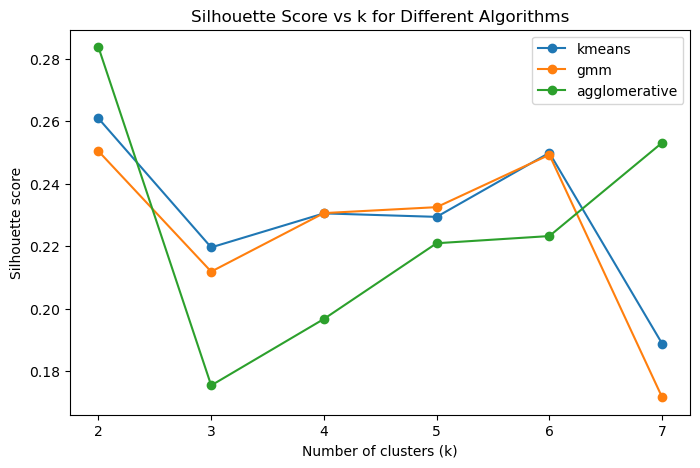

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for algo in results_df['algorithm'].unique():
    sub = results_df[results_df['algorithm'] == algo]
    ax.plot(sub['k'], sub['silhouette'], marker='o', label=algo)

ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Score vs k for Different Algorithms")
ax.legend()
plt.show()


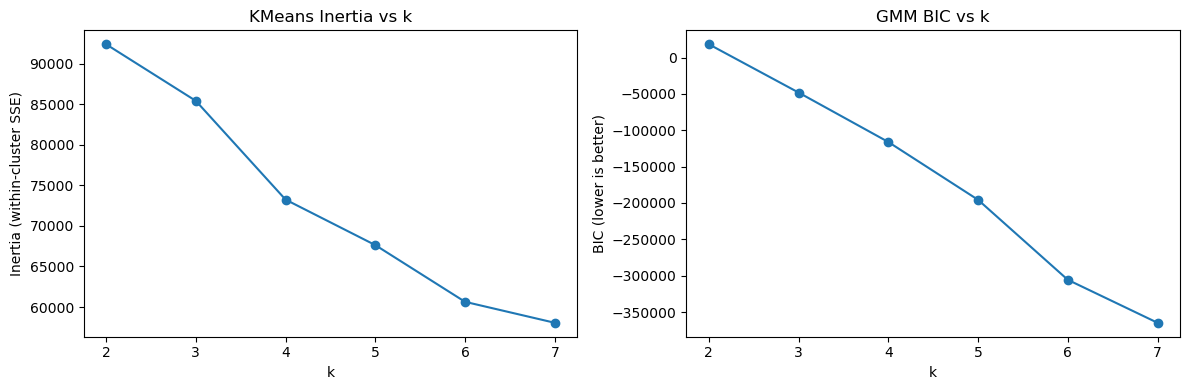

In [12]:
# KMeans Inertia
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

kmeans_sub = results_df[results_df['algorithm'] == 'kmeans']
ax[0].plot(kmeans_sub['k'], kmeans_sub['inertia'], marker='o')
ax[0].set_title("KMeans Inertia vs k")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia (within-cluster SSE)")

# GMM BIC
gmm_sub = results_df[results_df['algorithm'] == 'gmm']
ax[1].plot(gmm_sub['k'], gmm_sub['bic'], marker='o')
ax[1].set_title("GMM BIC vs k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("BIC (lower is better)")

plt.tight_layout()
plt.show()


-Although Agglomerative clustering with k=2 achieved the highest silhouette score, a 2-cluster solution oversimplifies traffic behavior and is not useful for adaptive traffic control.

-But silhouette drop between k=2 → k=4 is not dramatic, meaning more clusters are still valid.

-Also, inertia (for KMeans) shows the elbow flattening around K=4–6.

-Based on a balance of statistical performance, interpretability, and system requirements, K-Means with k=4 was selected as the final clustering model.